#### Transformasi Data

In [1]:
import pandas as pd

# Membuat data
data = {'Name': ['John', 'Jane', 'Jim', 'Jill', 'Jake'],
        'Gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
        'Age': [25, 30, 35, 40, 50],
        'Country': ['USA', 'UK', 'Canada', 'Australia', 'Germany']}
df = pd.DataFrame(data)

# Mengubah data kategorikal menjadi numerik dengan one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Gender', 'Country'],
                            prefix=['Gender', 'Country'])

# Menampilkan hasil
print("Data Before Encoding:")
print(df)
print("\nData After Encoding:")
print(df_encoded)

Data Before Encoding:
   Name  Gender  Age    Country
0  John    Male   25        USA
1  Jane  Female   30         UK
2   Jim    Male   35     Canada
3  Jill  Female   40  Australia
4  Jake    Male   50    Germany

Data After Encoding:
   Name  Age  Gender_Female  Gender_Male  Country_Australia  Country_Canada  \
0  John   25          False         True              False           False   
1  Jane   30           True        False              False           False   
2   Jim   35          False         True              False            True   
3  Jill   40           True        False               True           False   
4  Jake   50          False         True              False           False   

   Country_Germany  Country_UK  Country_USA  
0            False       False         True  
1            False        True        False  
2            False       False        False  
3            False       False        False  
4             True       False        False  


#### Transformasi Atribut Waktu

In [3]:
import pandas as pd

# 1. Membuat data dummy sebanyak 10 baris
data = {
    'date': ['2023-10-01', '2023-10-02', '2023-10-03', '2023-10-04', '2023-10-05',
             '2023-10-06', '2023-10-07', '2023-10-08', '2023-10-09', '2023-10-10'],
    'time': ['08:30:00', '09:45:15', '10:15:30', '11:00:45', '12:30:00',
             '13:45:15', '15:20:30', '16:50:45', '18:10:00', '20:05:15']
}
df = pd.DataFrame(data)

print("Data Sebelum Transformasi:")
print(df)
print("-" * 50)

# 2. Convert date and time columns to datetime format
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')

# 3. Extract features from date and time columns
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['time'].dt.hour
df['minute'] = df['time'].dt.minute
df['second'] = df['time'].dt.second

# 4. Drop original date and time columns
df.drop(['date', 'time'], axis=1, inplace=True)

# 5. Preview the new dataframe (menampilkan seluruh 10 baris)
print("\nData Setelah Transformasi:")
print(df)

Data Sebelum Transformasi:
         date      time
0  2023-10-01  08:30:00
1  2023-10-02  09:45:15
2  2023-10-03  10:15:30
3  2023-10-04  11:00:45
4  2023-10-05  12:30:00
5  2023-10-06  13:45:15
6  2023-10-07  15:20:30
7  2023-10-08  16:50:45
8  2023-10-09  18:10:00
9  2023-10-10  20:05:15
--------------------------------------------------

Data Setelah Transformasi:
   year  month  day  hour  minute  second
0  2023     10    1     8      30       0
1  2023     10    2     9      45      15
2  2023     10    3    10      15      30
3  2023     10    4    11       0      45
4  2023     10    5    12      30       0
5  2023     10    6    13      45      15
6  2023     10    7    15      20      30
7  2023     10    8    16      50      45
8  2023     10    9    18      10       0
9  2023     10   10    20       5      15


#### Deteksi Data Outlier

Data Outlier:
   Age  Income  Spending  Savings  Investment
6   70  200000     15000    35000       20000
6   70  200000     15000    35000       20000
6   70  200000     15000    35000       20000


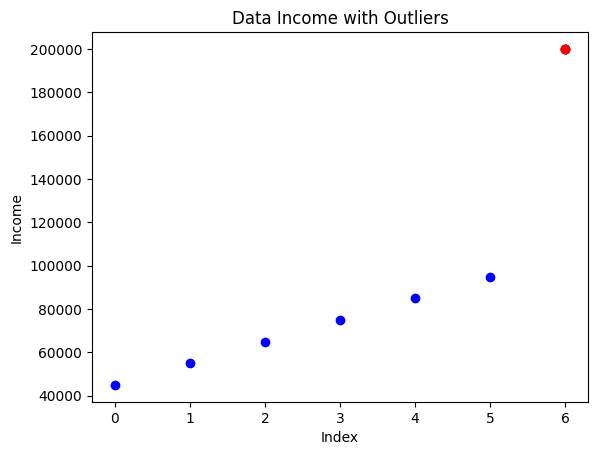

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Membuat fungsi untuk mendeteksi data outlier
def detect_outlier(df, n, features):
    outlier_indices = []

    # Loop melalui setiap fitur
    for col in features:
        # Menghitung mean dan standard deviation
        Q1 = np.percentile(df[col], 25)
        Q3 = np.percentile(df[col], 75)
        IQR = Q3 - Q1
        upper_bound = Q3 + (1.5 * IQR)
        lower_bound = Q1 - (1.5 * IQR)

        # Loop melalui setiap data pada fitur
        for index in range(df[col].count()):
            if df[col][index] > upper_bound or df[col][index] < lower_bound:
                outlier_indices.append(index)

    # Menampilkan data outlier
    print("Data Outlier:")
    return df.iloc[outlier_indices]

# Membuat data
data = {'Age': [25, 30, 35, 40, 50, 60, 70],
        'Income': [45000, 55000, 65000, 75000, 85000, 95000, 200000],
        'Spending': [2000, 2500, 3000, 3500, 4000, 6000, 15000],
        'Savings': [15000, 17000, 20000, 22000, 25000, 30000, 35000],
        'Investment': [1000, 2000, 3000, 4000, 6000, 10000, 20000]}
df = pd.DataFrame(data)

# Mendeteksi data outlier
outliers = detect_outlier(df, 2, ['Income', 'Spending', 'Savings', 'Investment'])
print(outliers)

# Menambahkan visualisasi
plt.scatter(df.index, df['Income'], color='blue')
plt.scatter(outliers.index, outliers['Income'], color='red')
plt.xlabel('Index')
plt.ylabel('Income')
plt.title('Data Income with Outliers')
plt.show()

#### Menangani data Imbalance

In [5]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# 1. Membuat data dummy (10 baris dengan label tidak seimbang)
data = {
    'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],            # Indeks 0 (diabaikan saat split)
    'label': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],          # Indeks 1 (Target/y: 8 kelas 0, 2 kelas 1)
    'Feature_A': [1.2, 1.5, 1.1, 1.3, 1.4, 1.2, 1.6, 1.5, 5.1, 5.3], # Indeks 2 (Fitur)
    'Feature_B': [2.1, 2.2, 2.0, 2.1, 2.3, 2.0, 2.4, 2.1, 8.0, 8.5]  # Indeks 3 (Fitur)
}
df = pd.DataFrame(data)
print("Data Awal (Imbalance):")
print(df)
print("-" * 50)

# split features and labels
X = df.iloc[:, 2:].values  # Mengambil fitur dari kolom ke-2 sampai akhir
y = df.iloc[:, 1].values   # Mengambil target/label dari kolom ke-1

# hitung distribusi label
label_count = df.iloc[:, 1].value_counts()

# tampilkan hasil
print("\nDistribusi Label Sebelum SMOTE:")
print(label_count)

# apply SMOTE
# Ditambahkan k_neighbors=1 karena sampel minoritas (label 1) hanya berjumlah 2
oversample = SMOTE(k_neighbors=1, random_state=42)
X, y = oversample.fit_resample(X, y)

# save balanced data to a new CSV file
balanced_df = pd.DataFrame(X, columns=df.columns[2:])
balanced_df['label'] = y
new_label_count = balanced_df['label'].value_counts()

print("\nDistribusi Label Setelah SMOTE:")
print(new_label_count)

balanced_df.to_csv('balanced_data.csv', index=False)
print("\nDataframe Balanced:")
print(balanced_df)

Data Awal (Imbalance):
   ID  label  Feature_A  Feature_B
0   1      0        1.2        2.1
1   2      0        1.5        2.2
2   3      0        1.1        2.0
3   4      0        1.3        2.1
4   5      0        1.4        2.3
5   6      0        1.2        2.0
6   7      0        1.6        2.4
7   8      0        1.5        2.1
8   9      1        5.1        8.0
9  10      1        5.3        8.5
--------------------------------------------------

Distribusi Label Sebelum SMOTE:
label
0    8
1    2
Name: count, dtype: int64

Distribusi Label Setelah SMOTE:
label
0    8
1    8
Name: count, dtype: int64

Dataframe Balanced:
    Feature_A  Feature_B  label
0    1.200000   2.100000      0
1    1.500000   2.200000      0
2    1.100000   2.000000      0
3    1.300000   2.100000      0
4    1.400000   2.300000      0
5    1.200000   2.000000      0
6    1.600000   2.400000      0
7    1.500000   2.100000      0
8    5.100000   8.000000      1
9    5.300000   8.500000      1
10   5.219